<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Вывод</a></span></li></ul></div>

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

In [1]:
!pip install lightgbm -q

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

In [3]:
TEST_SIZE = 0.1
RANDOM_STATE = 12345
sns.set(rc={'figure.figsize' : (12, 6)})
sns.set(style='darkgrid')

In [4]:
# откроем данные из файла
try:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv', sep=',', index_col=[0], parse_dates=[0])
except:
    data = pd.read_csv('taxi.csv', sep=',', index_col=[0], parse_dates=[0])

In [5]:
# Отсортируем данные по возрастанию индексов
data.sort_index(inplace=True)

In [6]:
# Ресемплируем данные по 1 часу
data = data.resample('1H').sum()

In [7]:
# Посмотрим на первые 10 сторок
data.head(10)

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43
2018-03-01 05:00:00,6
2018-03-01 06:00:00,12
2018-03-01 07:00:00,15
2018-03-01 08:00:00,34


In [8]:
# Посмотрим на последение 10 сторок
data.tail(10)

,num_orders
datetime,
2018-08-31 14:00:00,133
2018-08-31 15:00:00,116
2018-08-31 16:00:00,197
2018-08-31 17:00:00,217
2018-08-31 18:00:00,207
2018-08-31 19:00:00,136
2018-08-31 20:00:00,154
2018-08-31 21:00:00,159
2018-08-31 22:00:00,223


In [9]:
# Посмотрим на общую информацию о данных
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


Данные предствлены в виде количества заказов за 1 час в период с 1 марта 2018 года по 31 августа 2018 года включительно. Данные не содеражт пропусков.

## Анализ

In [10]:
# Посмотрим на описательные статистики
data.describe().T

,count,mean,std,min,25%,50%,75%,max
num_orders,4416.0,84.422781,45.023853,0.0,54.0,78.0,107.0,462.0


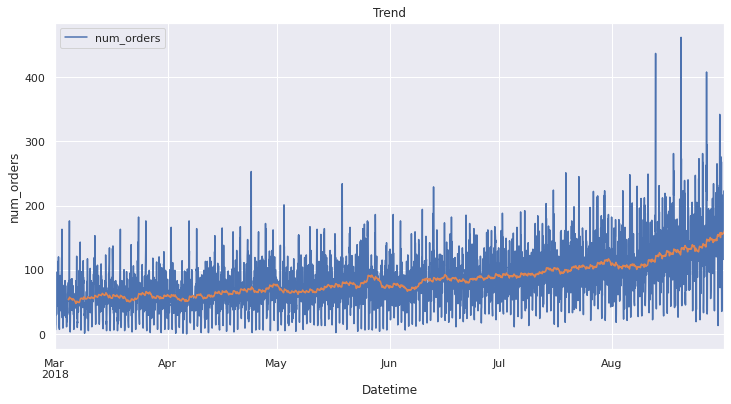

In [11]:
# Попробуем найти 
ax = plt.subplot()
data.plot(ax=ax)
data.rolling(90).mean().plot(ax=ax, 
                             legend=False, 
                             title='Trend', 
                             xlabel='Datetime', 
                             ylabel='num_orders')
plt.show()

In [12]:
# Разберем временной ряд на тренды и сезонность
decomposed = seasonal_decompose(data)

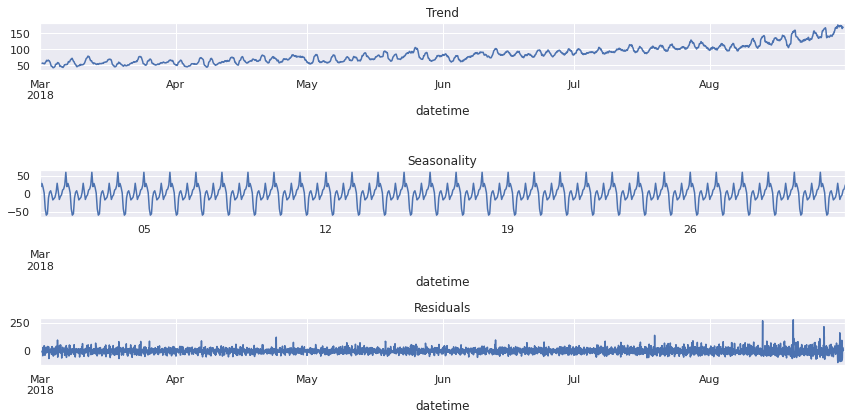

In [13]:
# Построим графики сезонной составляющей
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.subplot(312)
decomposed.seasonal['2018-03-01':'2018-03-31'].plot(ax=plt.gca())
plt.title('Seasonality')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuals')
plt.tight_layout()

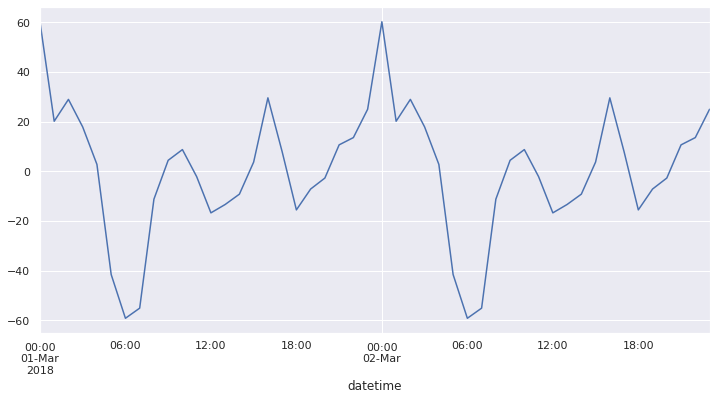

In [14]:
# Посмотрим подробней на сезонность, чтобы выявить циклично повторяющиеся закономерности внутри дня
decomposed.seasonal.head(48).plot();

Исходя из полученных данных, можно определить будущие признаки:
- явно выраженная сезонность в 24 часа
- восходящий тренд в количестве заказов от месяца к месяцу

In [15]:
# Функция создания новых признаков
def make_features(data, max_lag, rolling_mean_size):
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['hour'] = data.index.hour
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()
    data['rolling_std'] = data['num_orders'].shift().rolling(rolling_mean_size).std()

In [16]:
make_features(data, 24, 720)

In [17]:
data.dropna(inplace=True)

## Обучение

In [18]:
# Разбиваем данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('num_orders', axis=1),
    data['num_orders'],
    shuffle=False,
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE
)

X_train.shape, X_test.shape

((3326, 29), (370, 29))

In [19]:
lightgbm = LGBMRegressor(
    boosting_type='gbdt',
    objective='regression',
    metric='rmse',
    n_jobs=-1,
    random_state=RANDOM_STATE)

In [20]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('models',  LinearRegression())
])

In [21]:
# Гиперпараметры моделей и способы обработки количественных признаков
param_grid = [
    {
        'models': [LinearRegression()]
    },
    {
        'models': [RandomForestRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': [2, 4, 6],
        'models__max_features': [2, 4, 8],
        'models__min_samples_leaf': [2, 6, 10]
    },
     
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': [2, 4, 6],
        'models__max_features': ['auto', 5, 0.5],
        'models__min_samples_leaf': [2, 6, 10]
    },

        {
        'models': [lightgbm],    
        'models__learning_rate': [0.05, 0.1, 0.2],
        'models__num_leaves': [4, 16],
        'models__max_depth': [2, 4]  
    }
]

In [22]:
gs = GridSearchCV( 
    pipeline,
    param_grid, 
    scoring='neg_root_mean_squared_error', 
    cv=TimeSeriesSplit(n_splits=5)
)

In [23]:
gs.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('models', LinearRegression())]),
             param_grid=[{'models': [LinearRegression()]},
                         {'models': [RandomForestClassifier(random_state=12345)],
                          'models__max_depth': [2, 4, 6],
                          'models__max_features': [2, 4, 8],
                          'models__min_samples_...
                         {'models': [DecisionTreeRegressor(random_state=12345)],
                          'models__max_depth': [2, 4, 6],
                          'models__max_features': ['auto', 5, 0.5],
                          'models__min_samples_leaf': [2, 6, 10]},
                         {'models': [LGBMRegressor(max_depth=4, metric='rmse',
                                                   num_leaves=16,
                                       

In [24]:
round(gs.best_score_, 3)

-25.871

In [25]:
gs.best_params_

{'models': LGBMRegressor(max_depth=4, metric='rmse', num_leaves=16, objective='regression',
               random_state=12345),
 'models__learning_rate': 0.1,
 'models__max_depth': 4,
 'models__num_leaves': 16}

## Тестирование

In [26]:
# Метрика лучшей модели на тестовой выборке
round(mean_squared_error(y_test, gs.predict(X_test), squared= False), 3)

42.4

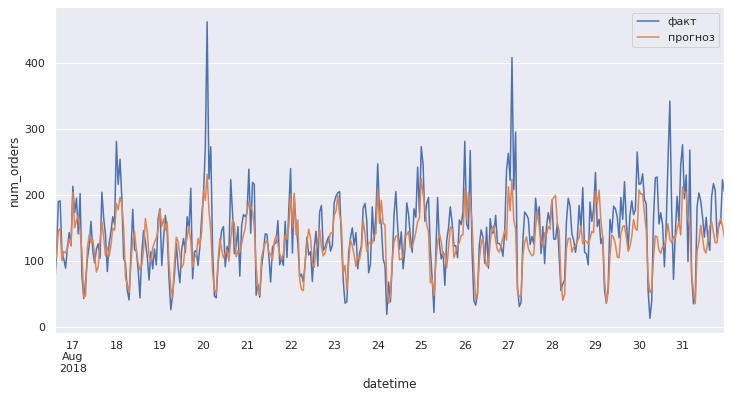

In [27]:
# Визуализируем фактические данные и предсказания лучшей модели
pd.DataFrame(data=zip(y_test, gs.predict(X_test)),
             index=y_test.index,
             columns=['факт', 'прогноз']).plot(grid=True, legend=True, xlabel='datetime', ylabel='num_orders');

Стоит отметить, что модель плохо справляется с аномальными значениями.

**Анализ важности признаков**

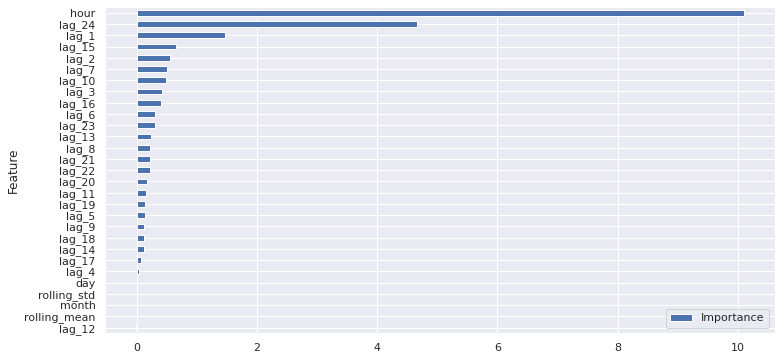

In [29]:
# Для оценки важности признаков модели воспользуемся инструментом permutation_importance
result = permutation_importance(gs, X_test, y_test, scoring='neg_root_mean_squared_error')

feature_importance = pd.DataFrame({'Feature': X_train.columns.tolist(), 'Importance': result['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh');

Наибольшее влияние оказывает признак кол-во поездок за час

## Вывод

В ходе проекта были обработаны данные о заказах такси. Для прогноза количества заказов такси использовали 4 различных алгоритма. Самой эффективной является модель градиентного бустинга библиотеки LightGBM с результатом на тестовых данных  RSME=42,4. Требование заказчика о значении метрики было выполнено.

Так же стоит отметить, что для модели наиболее важными признаками кол-во поездок в час. И, то что в бизнесе прослеживается восходящий тренд в количестве заказов от месяца к месяцу.